# Capstone Function 8
You’re optimising an eight-dimensional black-box function, where each of the eight input parameters affects the output, but the internal mechanics are unknown. 

Your objective is to find the parameter combination that maximises the function’s output, such as performance, efficiency or validation accuracy. Because the function is high-dimensional and likely complex, global optimisation is hard, so identifying strong local maxima is often a practical strategy.

For example, imagine you’re tuning an ML model with eight hyperparameters: learning rate, batch size, number of layers, dropout rate, regularisation strength, activation function (numerically encoded), optimiser type (encoded) and initial weight range. Each input set returns a single validation accuracy score between 0 and 1. Your goal is to maximise this score.

 Input | Output | Goal |
|-------|--------|------|
| 8D Array (40, 8) | 1D Array (40, ) | Maximise |

# Exploratory Data Analysis

In [1]:
# load and view a .npy file
import numpy as np
from matplotlib import pyplot as plt
import sys
# load the .npy file
initial_inputs = np.load("data/initial_inputs.npy")
initial_outputs = np.load("data/initial_outputs.npy")
# summarize shape
print(initial_inputs.shape)
print(initial_outputs.shape)

# create a dataframe from inputs and outputs
import pandas as pd
data = pd.DataFrame(initial_inputs, columns=[f'input_{i}' for i in range(initial_inputs.shape[1])])
data['output'] = initial_outputs
print(data.head(40))

# save the data as a CSV file
data.to_csv("data/initial_data.csv", index=False)

(40, 8)
(40,)
     input_0   input_1   input_2   input_3   input_4   input_5   input_6  \
0   0.604994  0.292215  0.908453  0.355506  0.201669  0.575338  0.310311   
1   0.178007  0.566223  0.994862  0.210325  0.320153  0.707909  0.635384   
2   0.009077  0.811626  0.520520  0.075687  0.265112  0.091652  0.592415   
3   0.506028  0.653730  0.363411  0.177981  0.093728  0.197425  0.755827   
4   0.359909  0.249076  0.495997  0.709215  0.114987  0.289207  0.557295   
5   0.778818  0.003419  0.337983  0.519528  0.820907  0.537247  0.551347   
6   0.908649  0.062250  0.238260  0.766604  0.132336  0.990244  0.688068   
7   0.586371  0.880736  0.745021  0.546035  0.009649  0.748992  0.230907   
8   0.761137  0.854672  0.382124  0.337352  0.689708  0.309853  0.631380   
9   0.984933  0.699506  0.998885  0.180148  0.580143  0.231087  0.490827   
10  0.112071  0.437736  0.596599  0.592776  0.226982  0.410105  0.921238   
11  0.791888  0.576191  0.694528  0.283424  0.136755  0.279162  0.842767  

## Observations


# Gaussian Process with EI, PI and UCB

Next sample UCB: [0.1959799 0.5       0.5       0.5       0.5       0.5       0.5
 0.5      ]
Next sample EI: [0.  0.5 0.5 0.5 0.5 0.5 0.5 0.5]
Next sample PI: [0.  0.5 0.5 0.5 0.5 0.5 0.5 0.5]


/Users/brucediesel/.pyenv/versions/3.13.3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 7 of parameter length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


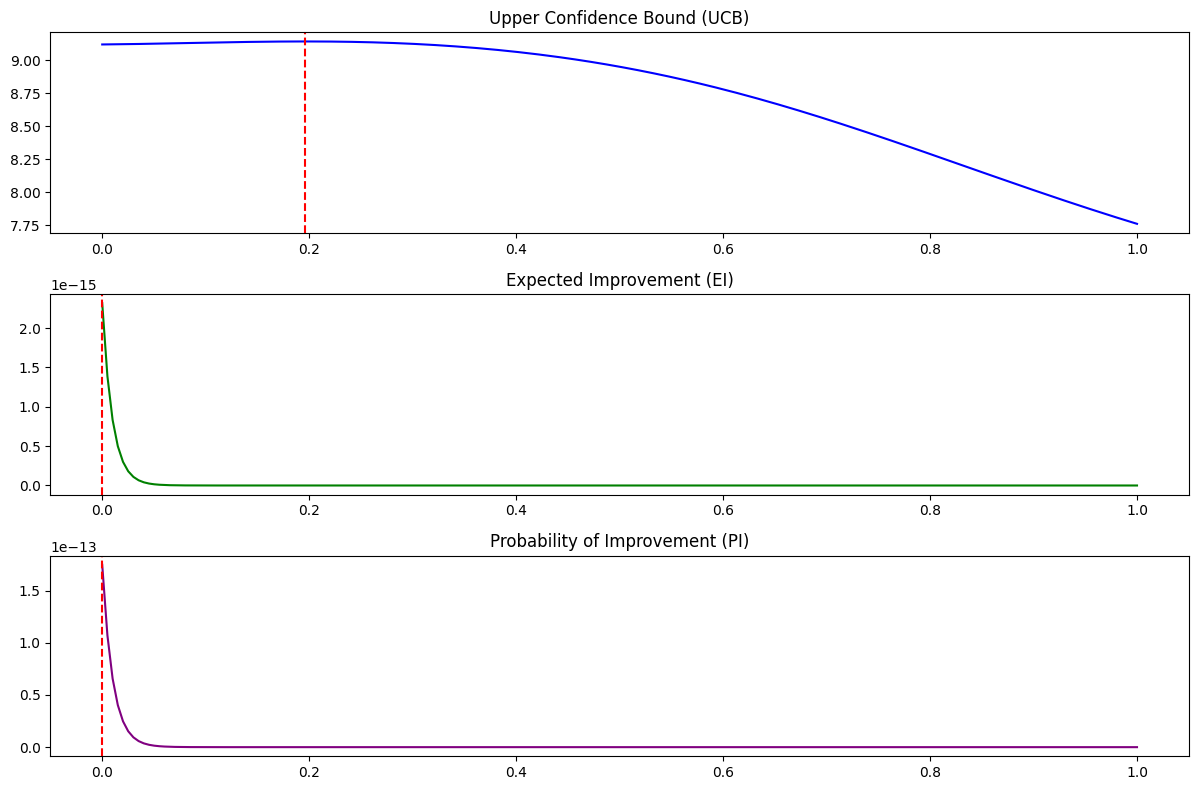

In [2]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from scipy.stats import norm

# Load the dataset
X = np.load("initial_inputs.npy")
y = np.load("initial_outputs.npy")

# Fit GP with Matern kernel
kernel = Matern(length_scale=np.ones(8), nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, normalize_y=True)
gp.fit(X, y)

# Candidate points (vary first dimension)
n_candidates = 200
X_candidates = np.zeros((n_candidates, 8))
X_candidates[:, 0] = np.linspace(0, 1, n_candidates)
X_candidates[:, 1:] = 0.5

# Predictions
mu, sigma = gp.predict(X_candidates, return_std=True)
y_best = np.max(y)

# Acquisition functions
def UCB(mu, sigma, kappa=2.5): return mu + kappa * sigma
def EI(mu, sigma, y_best):
    improvement = mu - y_best
    Z = improvement / sigma
    return improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
def PI(mu, sigma, y_best):
    Z = (mu - y_best) / sigma
    return norm.cdf(Z)

ucb_values, ei_values, pi_values = UCB(mu, sigma), EI(mu, sigma, y_best), PI(mu, sigma, y_best)

# Next samples
next_ucb, next_ei, next_pi = X_candidates[np.argmax(ucb_values)], X_candidates[np.argmax(ei_values)], X_candidates[np.argmax(pi_values)]
print("Next sample UCB:", next_ucb)
print("Next sample EI:", next_ei)
print("Next sample PI:", next_pi)

# Visualisation
plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
plt.plot(X_candidates[:, 0], ucb_values, 'b', label='UCB')
plt.axvline(next_ucb[0], color='r', linestyle='--')
plt.title('Upper Confidence Bound (UCB)')
plt.subplot(3, 1, 2)
plt.plot(X_candidates[:, 0], ei_values, 'g', label='EI')
plt.axvline(next_ei[0], color='r', linestyle='--')
plt.title('Expected Improvement (EI)')
plt.subplot(3, 1, 3)
plt.plot(X_candidates[:, 0], pi_values, 'purple', label='PI')
plt.axvline(next_pi[0], color='r', linestyle='--')
plt.title('Probability of Improvement (PI)')
plt.tight_layout()
plt.show()


## Observations
The choice for next sample is clearly nonsense.  With resort to random sample to start with, then improve my knowledge on how to get meaningful reults from these algorithms.

# Random Generation of next sample point

In [3]:
random_numbers = [np.random.random() for _ in range(8)]
print(random_numbers)

[0.3695108762344287, 0.3637354527597678, 0.19807354850799008, 0.8629644058690805, 0.35583667154815124, 0.5197758880675554, 0.2580107128712287, 0.6768046768685358]


# Week 1 Submission
0.369510-0.363735-0.198073-0.862964-0.355836-0.519775-0.258010-0.676804

---
---
# Week 2
Try to improve the process:
1. Build a SMBO (Sequential Model Based Optimisation) process to iteratively add new samples as they become available.
2. Visualize the performance - convergence
3. True to improve the various parameters!
4. Review which acquisition function to use

Suggested new points: [[0.09955011958120474, 0.14555163200711227, 0.06220500364423952, 0.07492772824084286, 1.0, 0.8823077949105924, 0.41717174535112694, 1.0]]


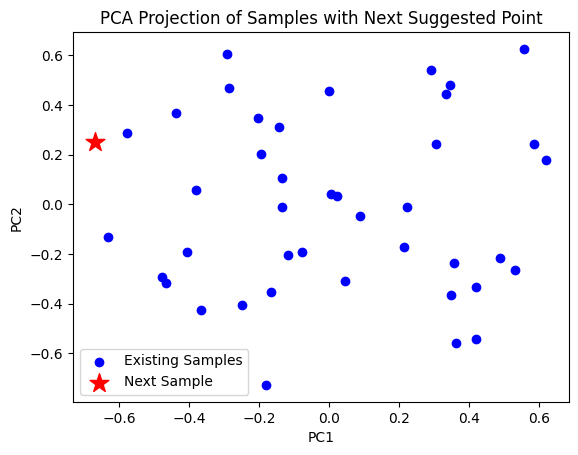

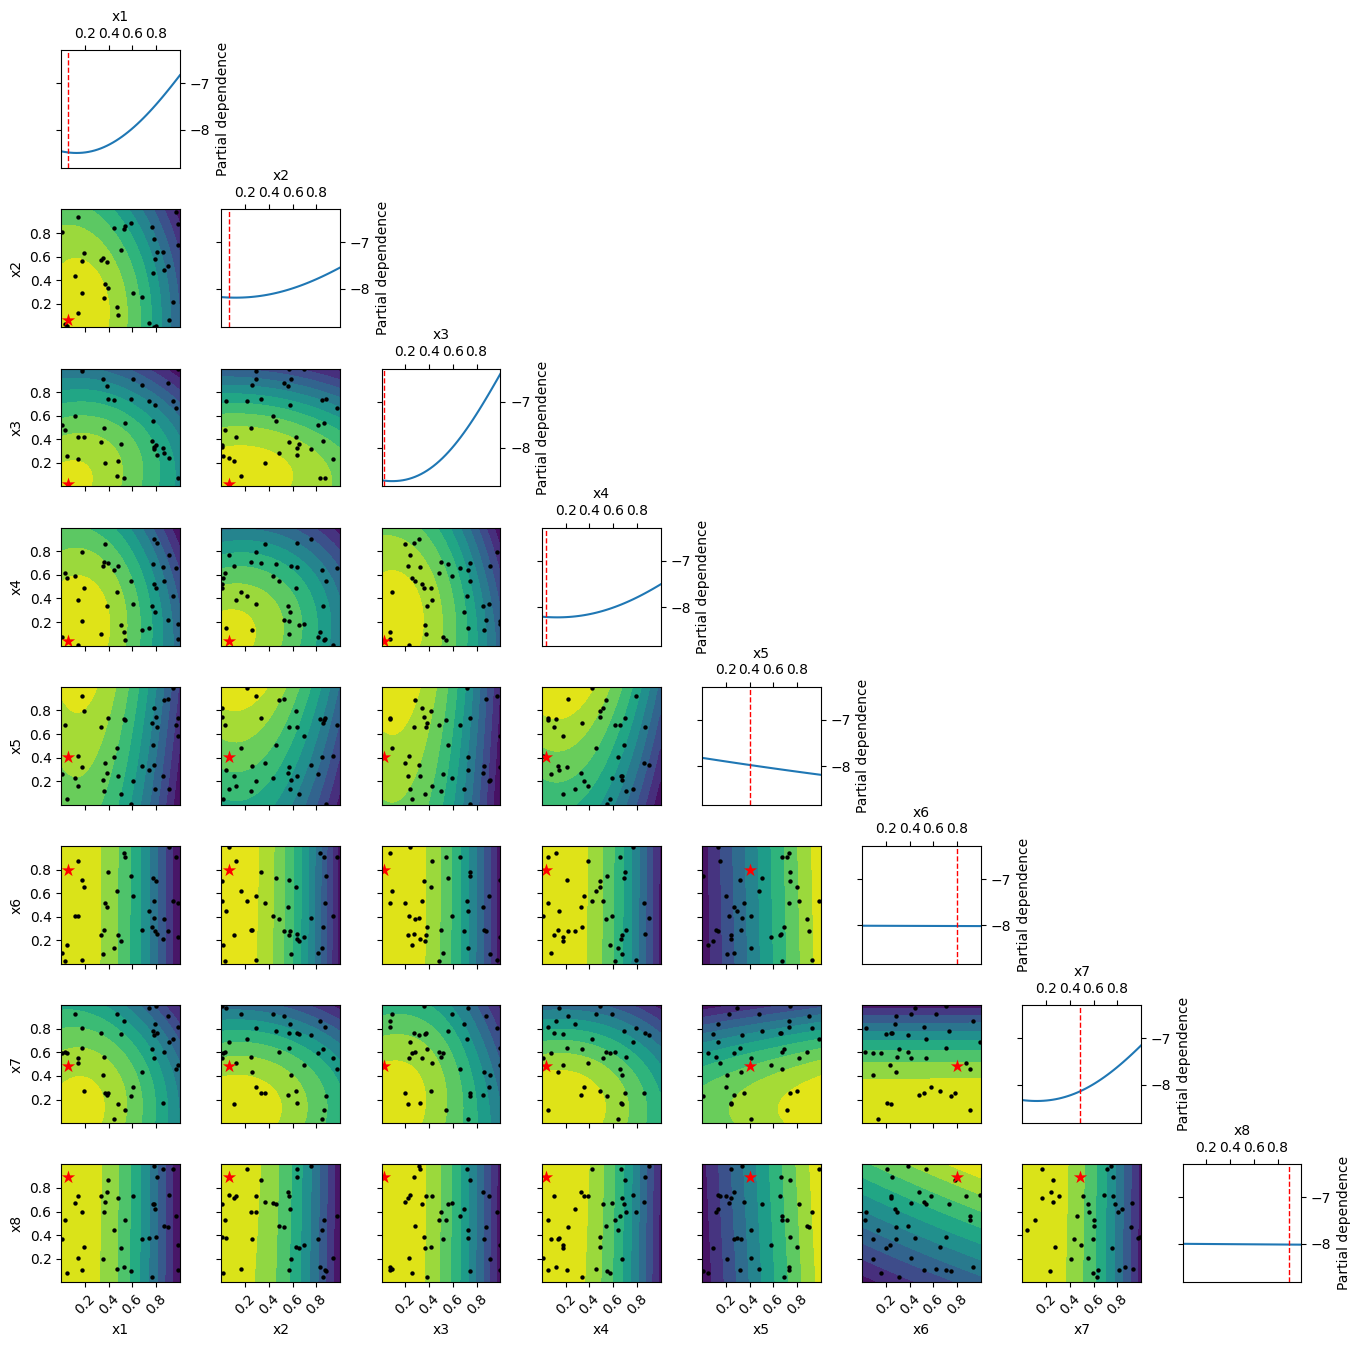

In [3]:

from skopt import Optimizer
from skopt.plots import plot_objective
from skopt.space import Real
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Define search space
space = [Real(0.0, 1.0, name='x1'),
         Real(0.0, 1.0, name='x2'),
         Real(0.0, 1.0, name='x3'),
         Real(0.0, 1.0, name='x4'),
         Real(0.0, 1.0, name='x5'),
         Real(0.0, 1.0, name='x6'),
         Real(0.0, 1.0, name='x7'),
         Real(0.0, 1.0, name='x8')]

# 2. Create Optimizer
opt = Optimizer(dimensions=space, base_estimator="GP", acq_func="PI", random_state=42)

# 3. Existing data (10 samples)
X = np.load("data/initial_inputs.npy").tolist()
y = np.load("data/initial_outputs.npy").tolist()

# insert a new observation at end of X and y (negate y for maximisation)
X.append([0.369510, 0.363735, 0.198073, 0.862964, 0.355836, 0.519775, 0.258010, 0.676804])
y.append(9.180474)

# negate the y values for maximisation
y = [-val for val in y]

# 4. Seed the optimiser
res = opt.tell(X, y)

# 5. Ask for new candidate points (no objective function needed)
next_points = opt.ask(n_points=1)  # propose new point
print("Suggested new points:", next_points)

# Use PCA to plot the next sample in 2D
pca = PCA(n_components=2)
proj = pca.fit_transform(np.array(X + next_points))
plt.scatter(proj[:-1, 0], proj[:-1, 1], c='blue', label='Existing Samples')
plt.scatter(proj[-1, 0], proj[-1, 1], c='red', label='Next Sample', marker='*', s=200)
plt.title('PCA Projection of Samples with Next Suggested Point')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

_ = plot_objective(res)


## Submission
0.099550-0.145551-0.062205-0.074927-1.000000-0.882307-0.417171-1.000000

---
---
# Week 3

Suggested new point: 0.067328-0.056131-0.189199-0.000000-1.000000-0.411794-0.083345-0.000000


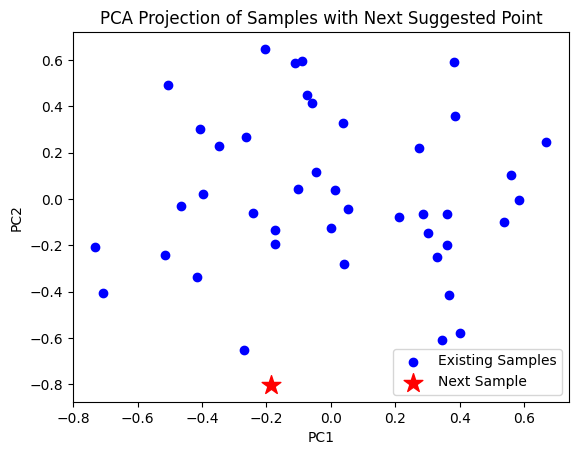

00. X: 0.604994, 0.292215, 0.908453, 0.355506, 0.201669, 0.575338, 0.310311, 0.734281, y:        7.398721
01. X: 0.178007, 0.566223, 0.994862, 0.210325, 0.320153, 0.707909, 0.635384, 0.107132, y:        7.005227
02. X: 0.009077, 0.811626, 0.520520, 0.075687, 0.265112, 0.091652, 0.592415, 0.367320, y:        8.459482
03. X: 0.506028, 0.653730, 0.363411, 0.177981, 0.093728, 0.197425, 0.755827, 0.292472, y:        8.284008
04. X: 0.359909, 0.249076, 0.495997, 0.709215, 0.114987, 0.289207, 0.557295, 0.593882, y:        8.606117
05. X: 0.778818, 0.003419, 0.337983, 0.519528, 0.820907, 0.537247, 0.551347, 0.660032, y:        8.541748
06. X: 0.908649, 0.062250, 0.238260, 0.766604, 0.132336, 0.990244, 0.688068, 0.742496, y:        7.327435
07. X: 0.586371, 0.880736, 0.745021, 0.546035, 0.009649, 0.748992, 0.230907, 0.097916, y:        7.299872
08. X: 0.761137, 0.854672, 0.382124, 0.337352, 0.689708, 0.309853, 0.631380, 0.041956, y:        7.957875
09. X: 0.984933, 0.699506, 0.998885, 0.180148,

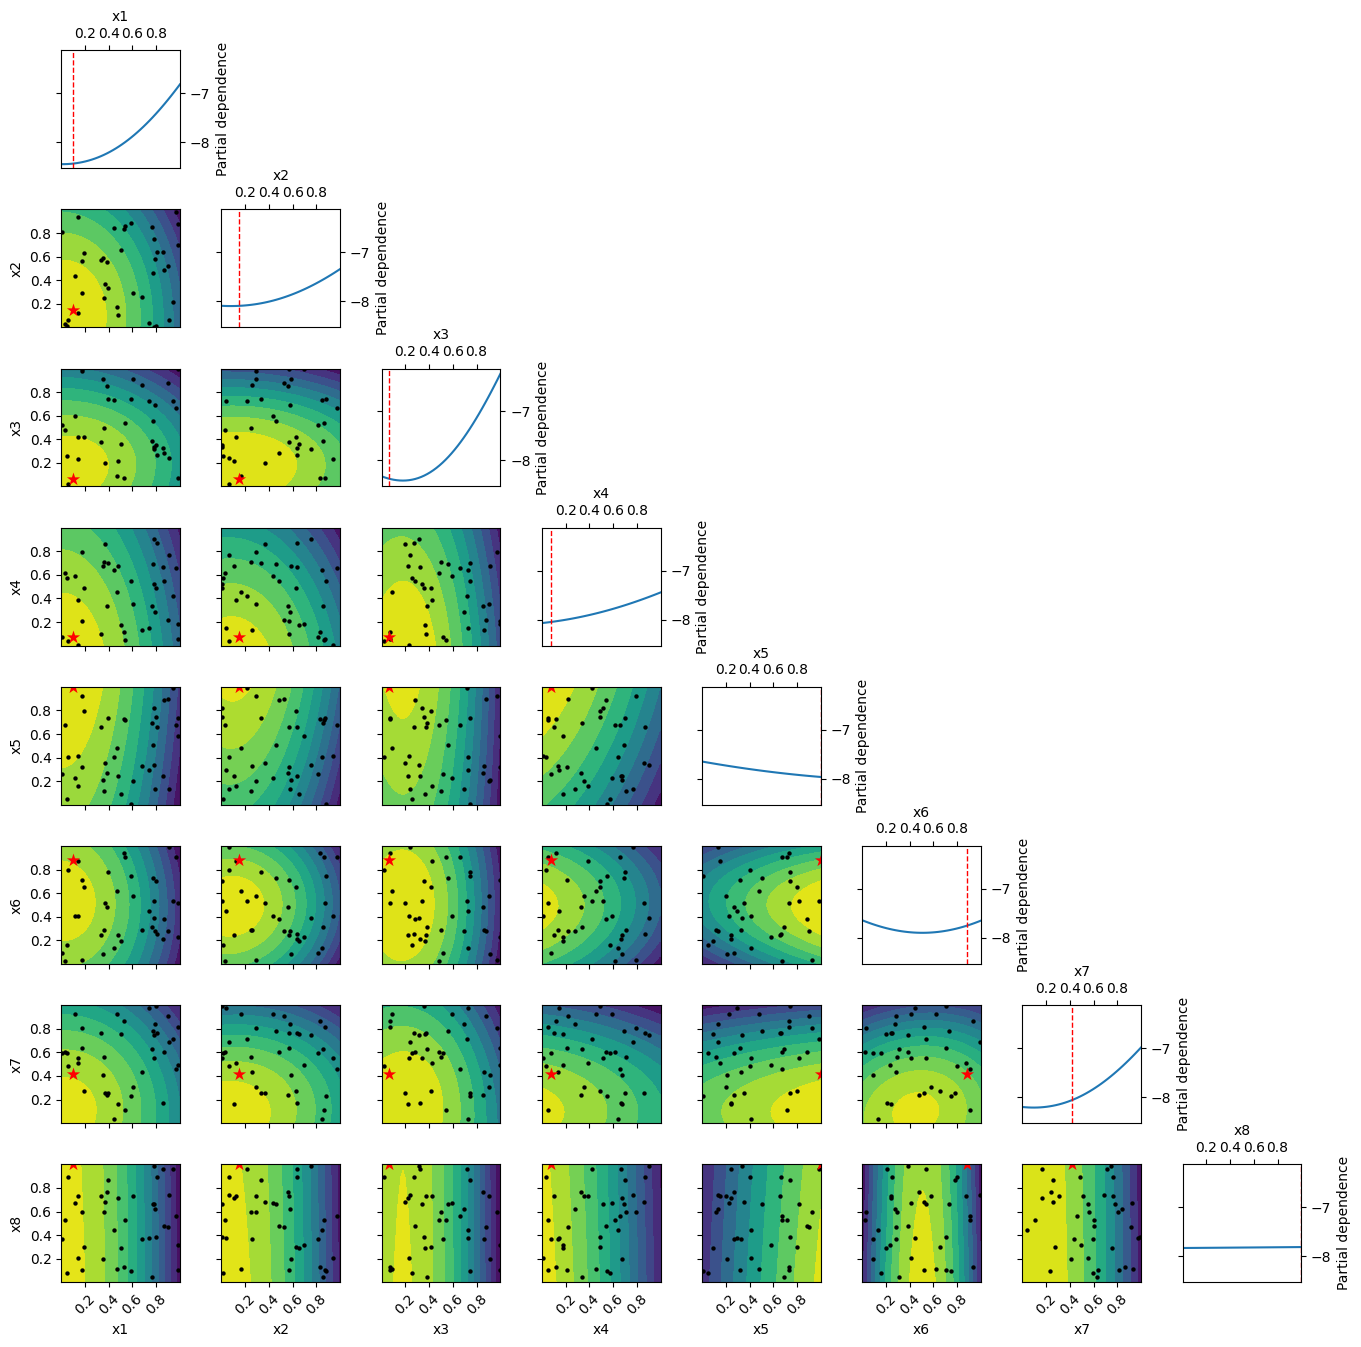

In [7]:

from skopt import Optimizer
from skopt.plots import plot_objective
from skopt.space import Real
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

# 1. Define search space
space = [Real(0.0, 1.0, name='x1'),
         Real(0.0, 1.0, name='x2'),
         Real(0.0, 1.0, name='x3'),
         Real(0.0, 1.0, name='x4'),
         Real(0.0, 1.0, name='x5'),
         Real(0.0, 1.0, name='x6'),
         Real(0.0, 1.0, name='x7'),
         Real(0.0, 1.0, name='x8')]

# 2. Create Optimizer
opt = Optimizer(dimensions=space, base_estimator="GP", acq_func="EI", random_state=42, acq_func_kwargs={'xi': 0.0})

# 3. Existing data (10 samples)
X = np.load("data/initial_inputs.npy").tolist()
y = np.load("data/initial_outputs.npy").tolist()

# insert a new observation Week 1
X.append([0.369510, 0.363735, 0.198073, 0.862964, 0.355836, 0.519775, 0.258010, 0.676804])
y.append(9.180474)

# insert a new observation Week 2
X.append([0.099550, 0.145551, 0.062205, 0.074927, 1.000000, 0.882307, 0.417171, 1.000000])
y.append(9.704070231264)

# negate the y values for maximisation
y = [-val for val in y]

# 4. Seed the optimiser
res = opt.tell(X, y)

# 5. Ask for new candidate points (no objective function needed)
next_point = opt.ask(n_points=1)  # propose new point
print(f"Suggested new point: {next_point[0][0]:.6f}-{next_point[0][1]:.6f}-{next_point[0][2]:.6f}-{next_point[0][3]:.6f}-{next_point[0][4]:.6f}-{next_point[0][5]:.6f}-{next_point[0][6]:.6f}-{next_point[0][7]:.6f}")

# Use PCA to plot the next sample in 2D
pca = PCA(n_components=2)
proj = pca.fit_transform(np.array(X + next_point))
plt.scatter(proj[:-1, 0], proj[:-1, 1], c='blue', label='Existing Samples')
plt.scatter(proj[-1, 0], proj[-1, 1], c='red', label='Next Sample', marker='*', s=200)
plt.title('PCA Projection of Samples with Next Suggested Point')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

_ = plot_objective(res)

# negate all the y values back to original
y = [-val for val in y]

# Print X and y in a formatted way with unpacked coordinates
max_y_index = np.argmax(y)
# Use fixed width for y column (easier to read)
for i in range(len(X)):
    x_str = ", ".join(f"{val:.6f}" for val in X[i])
    
    # Right-align y values in 15 character width
    y_str = f"{y[i]:>15.6f}"
    
    if i == max_y_index:
        print(f"{i:02d}. \033[92mX: {x_str}, y: {y_str}\033[0m")
    else:
        print(f"{i:02d}. X: {x_str}, y: {y_str}")



---
---
# Week 4

Suggested new point: 0.132486-0.145469-0.145046-0.112968-1.000000-0.420346-0.214975-1.000000


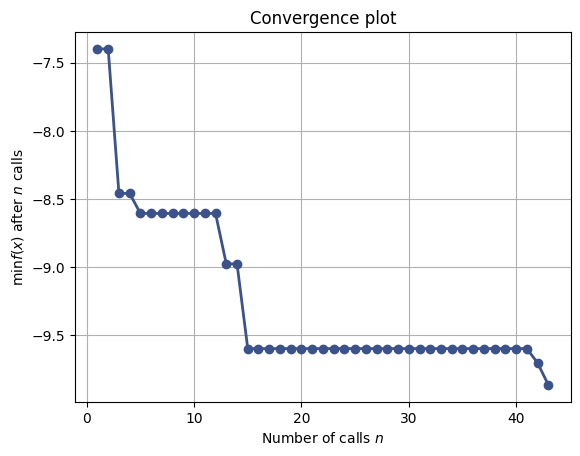

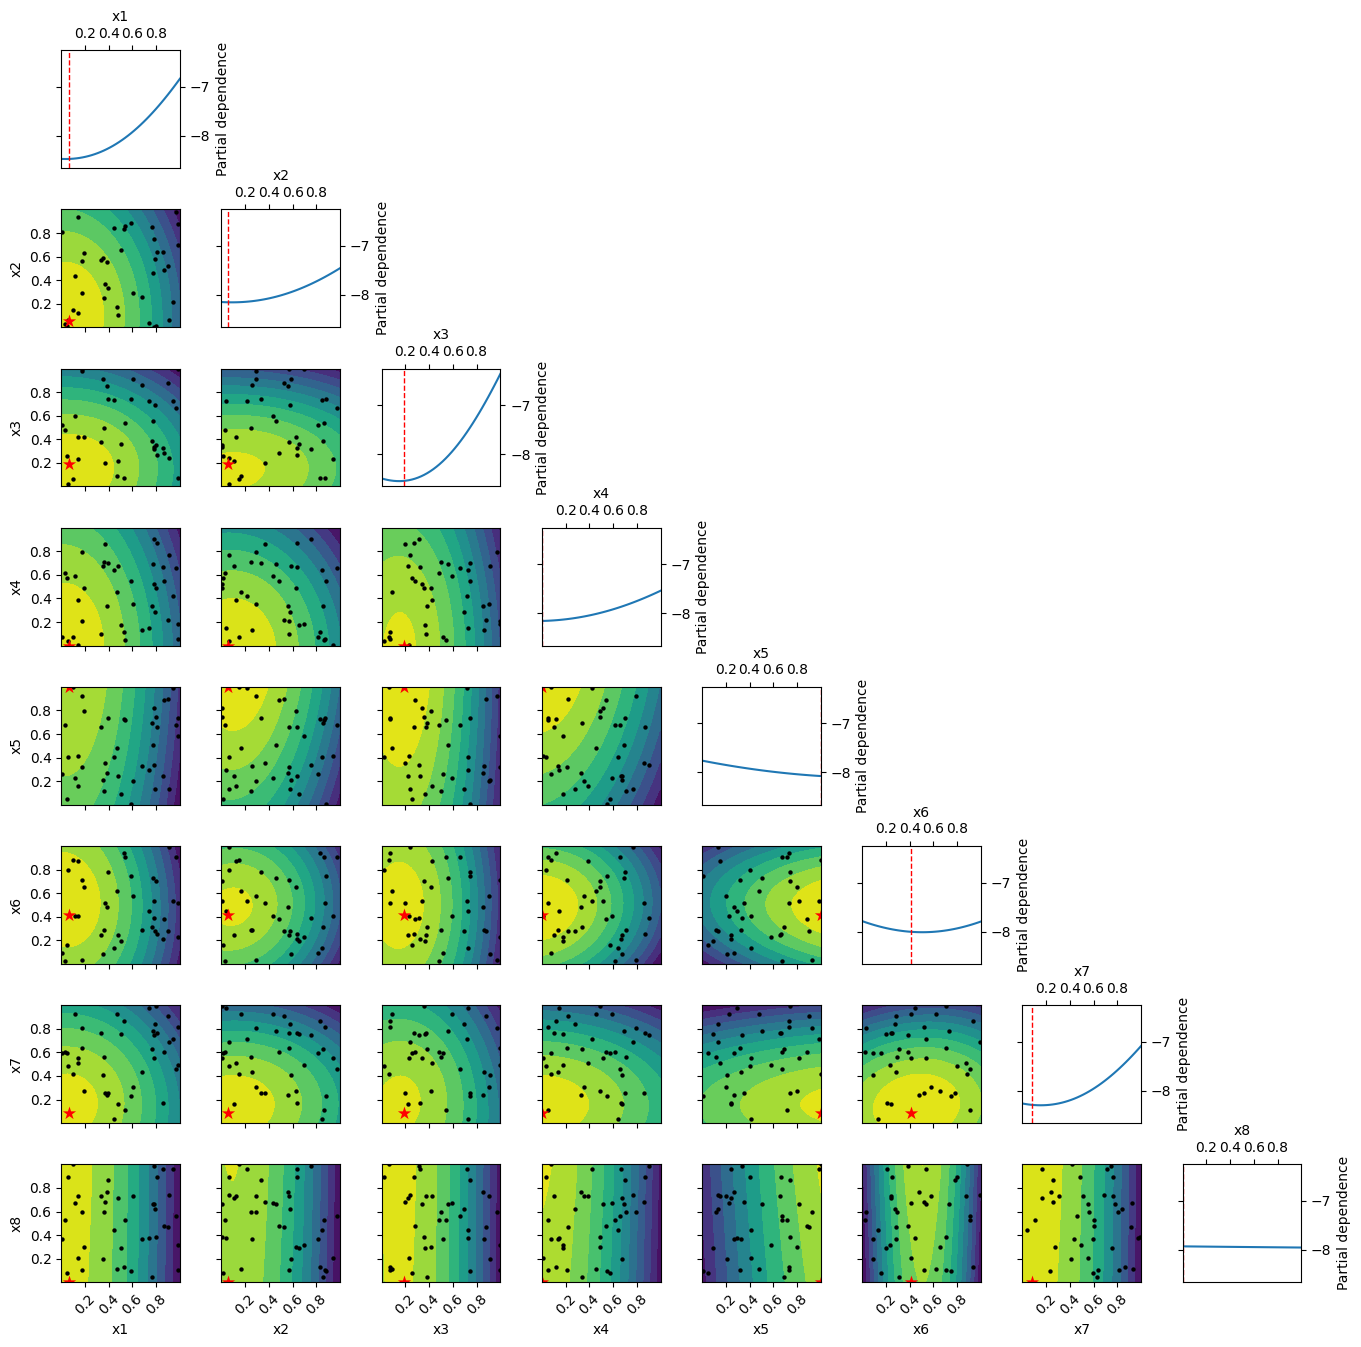

In [5]:
from skopt import Optimizer
from skopt.plots import plot_objective, plot_convergence, plot_gaussian_process
from skopt.space import Real
import numpy as np

# 1. Define search space
space = [Real(0.0, 1.0, name='x1'),
         Real(0.0, 1.0, name='x2'),
         Real(0.0, 1.0, name='x3'),
         Real(0.0, 1.0, name='x4'),
         Real(0.0, 1.0, name='x5'),
         Real(0.0, 1.0, name='x6'),
         Real(0.0, 1.0, name='x7'),
         Real(0.0, 1.0, name='x8')]

# set the hyperparameters for Optimizer
base_estimator = "GP"
acq_func = "EI"
random_state = 42
acq_func_kwargs = {'xi': 0.03}

# 2. Create Optimizer
opt = Optimizer(dimensions=space, base_estimator=base_estimator, acq_func=acq_func, random_state=random_state, acq_func_kwargs=acq_func_kwargs)

# 3. Existing data ()
X = np.load("../data/f8/updated_inputs.npy").tolist()
y = np.load("../data/f8/updated_outputs.npy").tolist()

# negate the y values for maximisation
y = [-val for val in y]

# 4. Seed the optimiser
res = opt.tell(X, y)

# 5. Ask for new candidate points (no objective function needed)
next_point = opt.ask(n_points=1)  # propose next point
print(f"Suggested new point: {next_point[0][0]:.6f}-{next_point[0][1]:.6f}-{next_point[0][2]:.6f}-{next_point[0][3]:.6f}-{next_point[0][4]:.6f}-{next_point[0][5]:.6f}-{next_point[0][6]:.6f}-{next_point[0][7]:.6f}")

# plot the convergence
__ = plot_convergence(res)

# plot the objective function
_ = plot_objective(res)


---
---
# Week 5

Suggested new point: 0.000000-0.034705-0.000000-0.309142-1.000000-0.420410-0.066877-1.000000


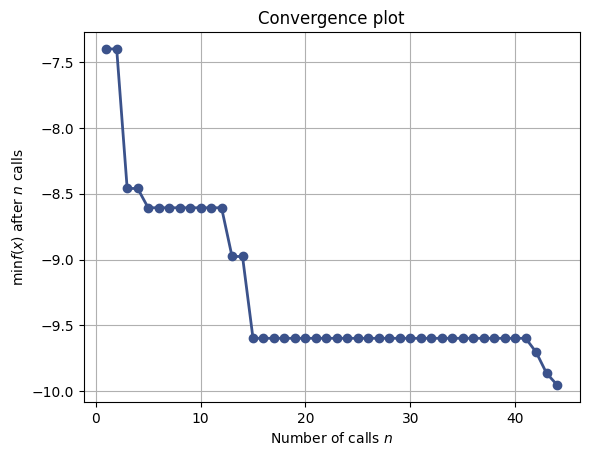

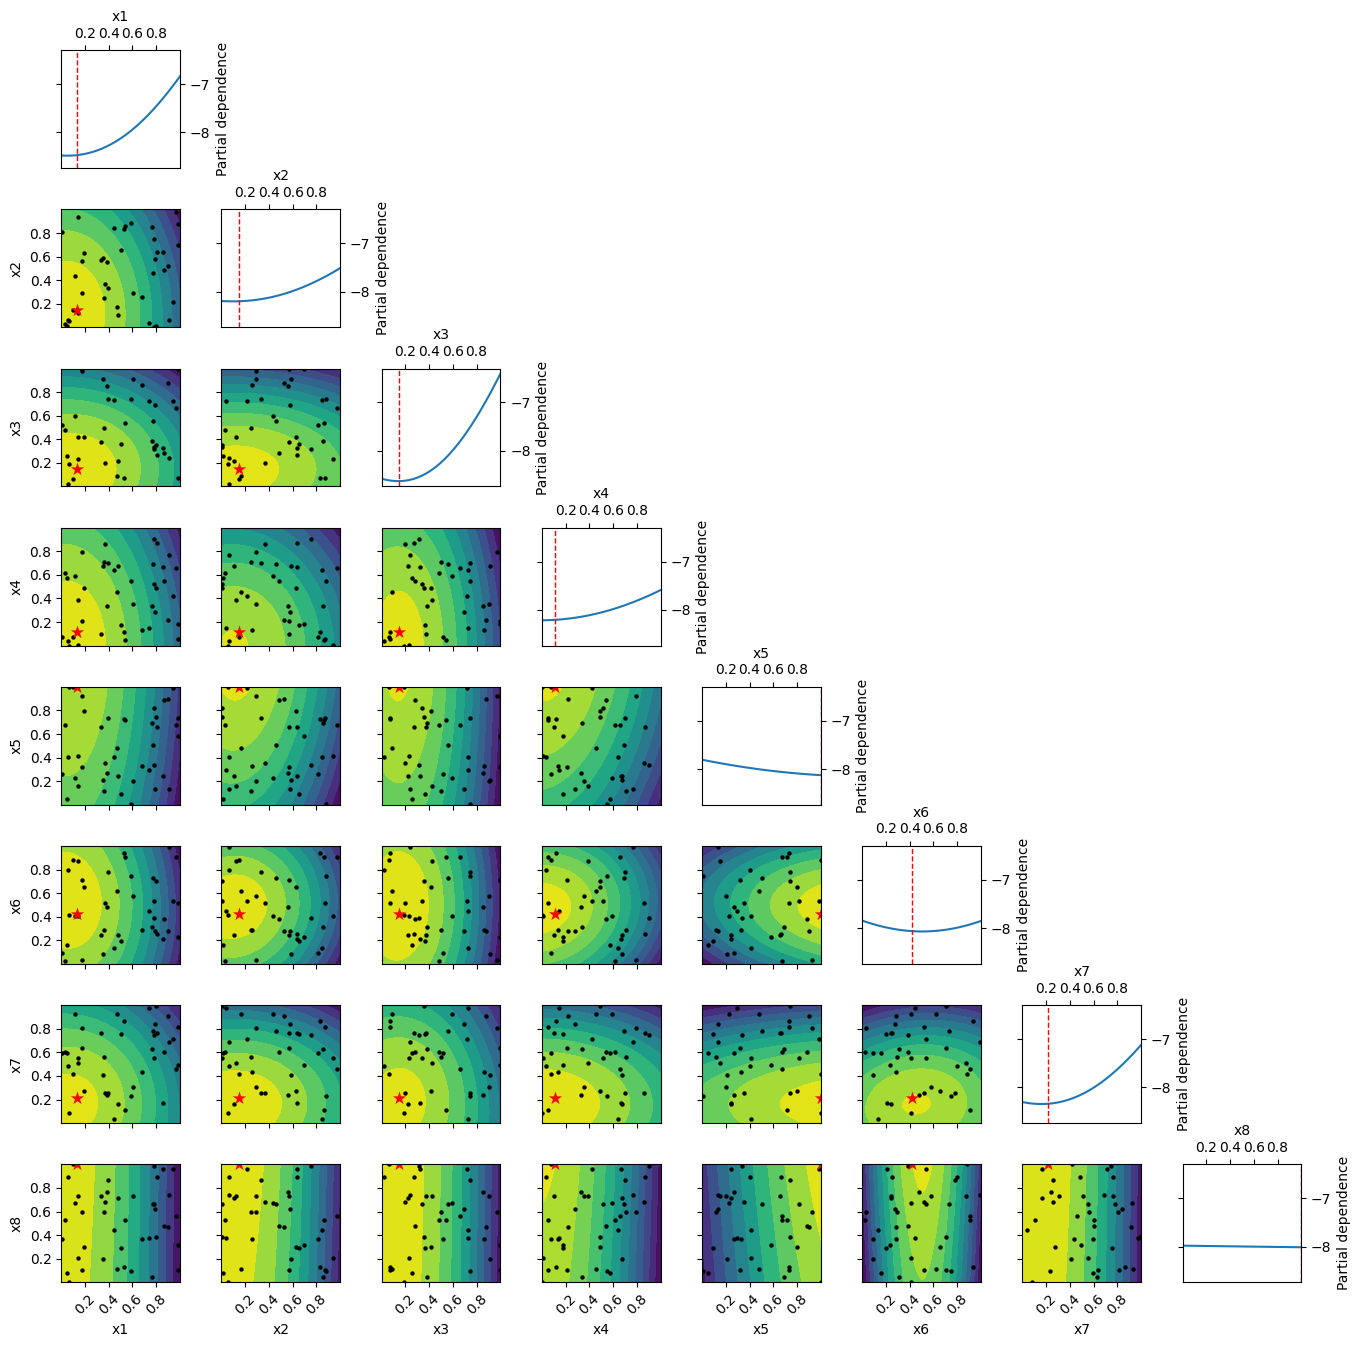

In [6]:
from skopt import Optimizer
from skopt.plots import plot_objective, plot_convergence, plot_gaussian_process
from skopt.space import Real
import numpy as np

# 1. Define search space
space = [Real(0.0, 1.0, name='x1'),
         Real(0.0, 1.0, name='x2'),
         Real(0.0, 1.0, name='x3'),
         Real(0.0, 1.0, name='x4'),
         Real(0.0, 1.0, name='x5'),
         Real(0.0, 1.0, name='x6'),
         Real(0.0, 1.0, name='x7'),
         Real(0.0, 1.0, name='x8')]

# set the hyperparameters for Optimizer
base_estimator = "GP"
acq_func = "EI"
random_state = 42
acq_func_kwargs = {'xi': 0.03}

# 2. Create Optimizer
opt = Optimizer(dimensions=space, base_estimator=base_estimator, acq_func=acq_func, random_state=random_state, acq_func_kwargs=acq_func_kwargs)

# 3. Existing data ()
X = np.load("../data/f8/updated_inputs - Week 4.npy").tolist()
y = np.load("../data/f8/updated_outputs - Week 4.npy").tolist()

# negate the y values for maximisation
y = [-val for val in y]

# 4. Seed the optimiser
res = opt.tell(X, y)

# 5. Ask for new candidate points (no objective function needed)
next_point = opt.ask(n_points=1)  # propose next point
print(f"Suggested new point: {next_point[0][0]:.6f}-{next_point[0][1]:.6f}-{next_point[0][2]:.6f}-{next_point[0][3]:.6f}-{next_point[0][4]:.6f}-{next_point[0][5]:.6f}-{next_point[0][6]:.6f}-{next_point[0][7]:.6f}")

# plot the convergence
__ = plot_convergence(res)

# plot the objective function
_ = plot_objective(res)
